In [ ]:
# CELDA 0 — Instalación de dependencias
!pip install -q optuna xgboost shap groq yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 9.8 MB/s eta 0:00:00


In [ ]:
# CELDA 1 — Setup, imports y configuración global
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Universo de activos (10 tickers diversificados)
# Tech grande + finanzas + consumo + salud => el modelo aprende patrones
# generales del mercado, no solo dinámicas de tech.
TICKERS = [
    "AAPL", "MSFT", "GOOG", "NFLX", "AMZN",   # Tech / consumer tech
    "JPM",  "V",                                # Finanzas
    "WMT",  "KO",                               # Consumo
    "JNJ",                                      # Salud
]

# Paleta por ticker (consistencia en todas las figuras del informe)
import matplotlib.cm as cm
COLORS = {t: cm.tab10(i % 10) for i, t in enumerate(TICKERS)}

# Estilo global de las figuras (calidad publicación)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,           # alta resolución para LaTeX
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.labelsize": 12,
})

# Configuración del problema
START_DATE   = "2020-01-01"      # 5 años de historia ~ 1250 sesiones/ticker
END_DATE     = "2024-12-31"
RETURN_THR   = 0.005             # umbral 0.5%: target = 1 si retorno > 0.5%
HORIZON_DAYS = 1                 # predecir el día siguiente

print(f"Universo: {len(TICKERS)} tickers")
print(f"Período: {START_DATE} a {END_DATE} (~{5*252} sesiones por ticker)")
print(f"Target: retorno t+{HORIZON_DAYS} > {RETURN_THR*100:.1f}%")

Universo: 10 tickers
Período: 2020-01-01 a 2024-12-31 (~1260 sesiones por ticker)
Target: retorno t+1 > 0.5%


Ticker    Sesiones   Nulos   Min Close   Max Close
--------------------------------------------------
AAPL          1257       0       54.16      257.38
MSFT          1257       0      128.64      461.32
GOOG          1257       0       52.40      197.25
NFLX          1257       0       16.64       93.66
AMZN          1257       0       81.82      232.93
JPM           1257       0       66.76      242.76
V             1257       0      129.76      317.33
WMT           1257       0       31.75       94.21
KO            1257       0       31.30       69.43
JNJ           1257       0       93.97      165.63

 Análisis de valores nulos por ticker
      close  high  low  open  volume  ticker
AAPL      0     0    0     0       0       0
MSFT      0     0    0     0       0       0
GOOG      0     0    0     0       0       0
NFLX      0     0    0     0       0       0
AMZN      0     0    0     0       0       0
JPM       0     0    0     0       0       0
V         0     0    0     0      

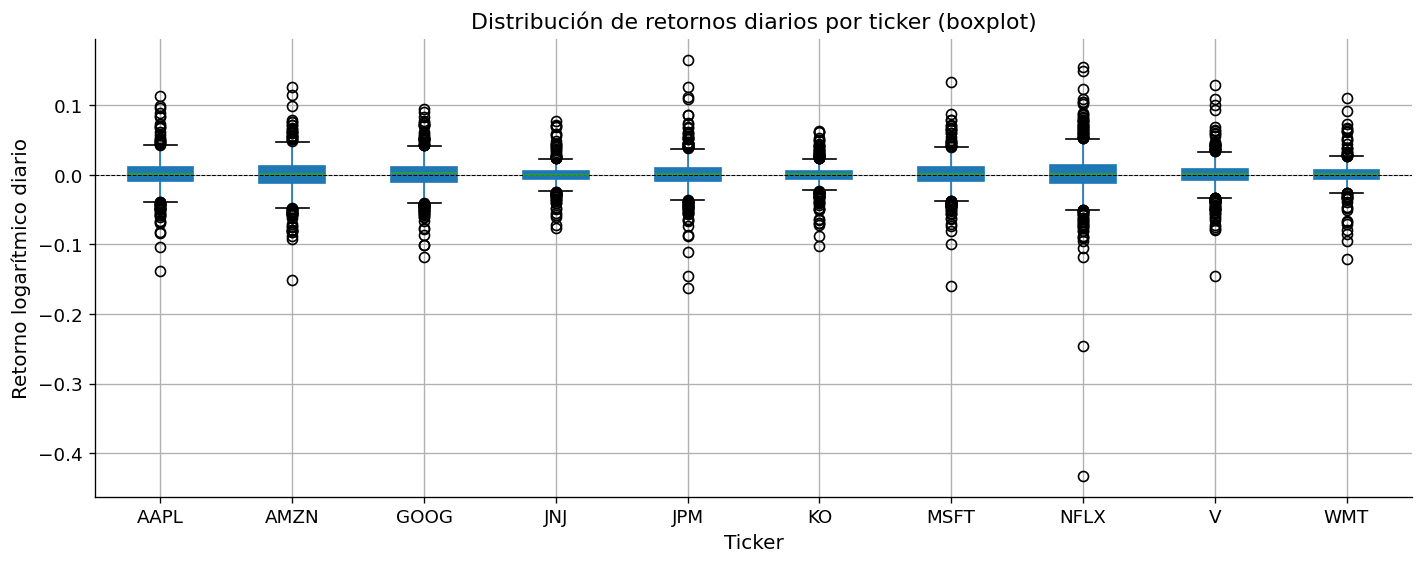

In [ ]:
# CELDA 2 — Descarga de datos + EDA: precio, nulos, outliers
import yfinance as yf

raw = {}
print(f"{'Ticker':<8}{'Sesiones':>10}{'Nulos':>8}{'Min Close':>12}{'Max Close':>12}")
print("-" * 50)
for ticker in TICKERS:
    df = yf.download(ticker, start=START_DATE, end=END_DATE,
                     auto_adjust=True, progress=False)
    # Normalizar nombres de columnas (yfinance a veces devuelve MultiIndex)
    df.columns = [c[0].lower() if isinstance(c, tuple) else c.lower()
                  for c in df.columns]
    df["ticker"] = ticker
    raw[ticker] = df
    n_nulls = df.isnull().sum().sum()
    print(f"{ticker:<8}{len(df):>10}{n_nulls:>8}"
          f"{df['close'].min():>12.2f}{df['close'].max():>12.2f}")

# ANÁLISIS EXPLÍCITO DE NULOS
print("\n Análisis de valores nulos por ticker")
nulls_df = pd.DataFrame({
    t: raw[t].isnull().sum() for t in TICKERS
}).T
print(nulls_df.to_string())
print(f"\nEstrategia: yfinance entrega datos limpios (sin nulos). "
      f"Los nulos que aparezcan tras feature engineering "
      f"(rolling windows iniciales) se eliminan con dropna() "
      f"porque corresponden a períodos donde los indicadores no "
      f"están definidos aún (e.g., primeras 20 sesiones para MA20).")

# ANÁLISIS DE OUTLIERS — retornos diarios extremos
returns_long = []
for t in TICKERS:
    r = np.log(raw[t]["close"] / raw[t]["close"].shift(1)).dropna()
    returns_long.append(pd.DataFrame({"ticker": t, "ret": r.values}))
returns_long = pd.concat(returns_long, ignore_index=True)

# Detección de outliers: |z-score| > 4 = movimientos de >4 sigmas
z = (returns_long["ret"] - returns_long["ret"].mean()) / returns_long["ret"].std()
outliers = returns_long[np.abs(z) > 4]
print(f"\n Outliers (|z-score| > 4 en retornos diarios)")
print(f"Total observaciones: {len(returns_long)}")
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(returns_long)*100:.2f}%)")
print(f"Estrategia: NO se eliminan. Los outliers son eventos de mercado reales "
      f"(crash COVID Mar-2020, rally tech 2021, caída 2022). Eliminarlos "
      f"sesgaría el modelo a no predecir movimientos significativos.")

# Boxplot de retornos por ticker — visualización de outliers
fig, ax = plt.subplots(figsize=(12, 5))
returns_long.boxplot(column="ret", by="ticker", ax=ax,
                     showfliers=True, patch_artist=True)
ax.set_title("Distribución de retornos diarios por ticker (boxplot)")
ax.set_xlabel("Ticker")
ax.set_ylabel("Retorno logarítmico diario")
plt.suptitle("")  # quitar título automático de pandas
ax.axhline(0, color="black", lw=0.6, ls="--")
plt.tight_layout()
plt.savefig("eda_outliers_boxplot.png")
plt.show()

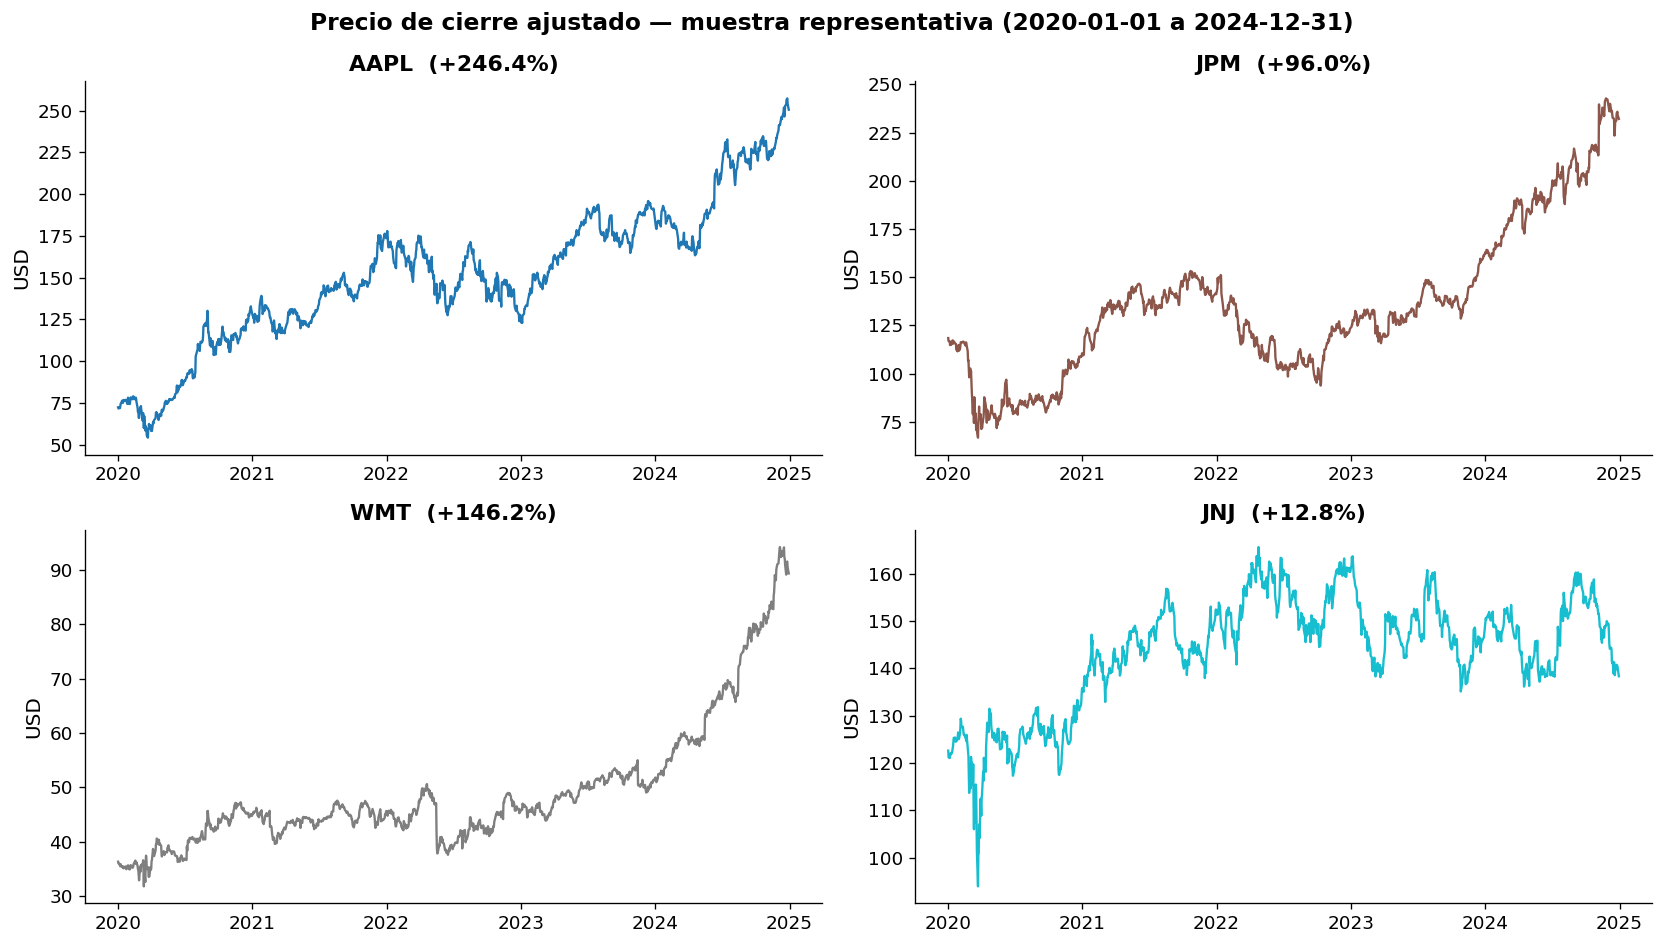

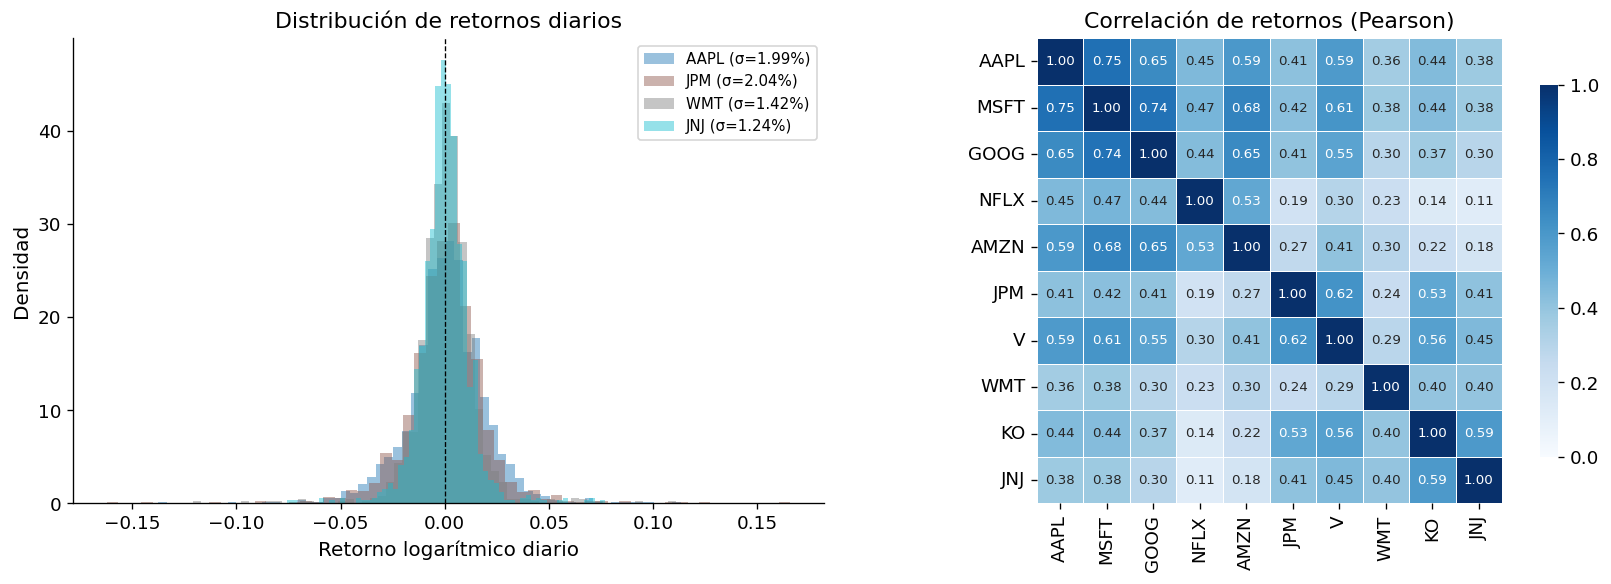


 Estadísticas de retornos diarios
      Media (%)  Volatilidad (%)  Min (%)  Max (%)  Skewness  Kurtosis
AAPL      0.099            1.995  -13.771   11.316   -11.335   537.900
MSFT      0.081            1.923  -15.945   13.293   -28.492   754.607
GOOG      0.083            2.042  -11.767    9.499   -23.644   370.240
NFLX      0.080            2.954  -43.258   15.576  -263.604  4229.189
AMZN      0.067            2.266  -15.140   12.695   -13.452   408.630
JPM       0.054            2.045  -16.211   16.562     0.254  1255.514
V         0.043            1.755  -14.557   12.965    -4.890  1026.393
WMT       0.072            1.423  -12.076   11.072   -27.310  1431.563
KO        0.022            1.317  -10.173    6.278   -85.395   916.978
JNJ       0.010            1.236   -7.578    7.694    25.077   807.956

 Dataset final tras feature engineering
Features:     17 indicadores técnicos
Filas totales: 12370
Balance target (% días con retorno > 0.5%): 36.5%


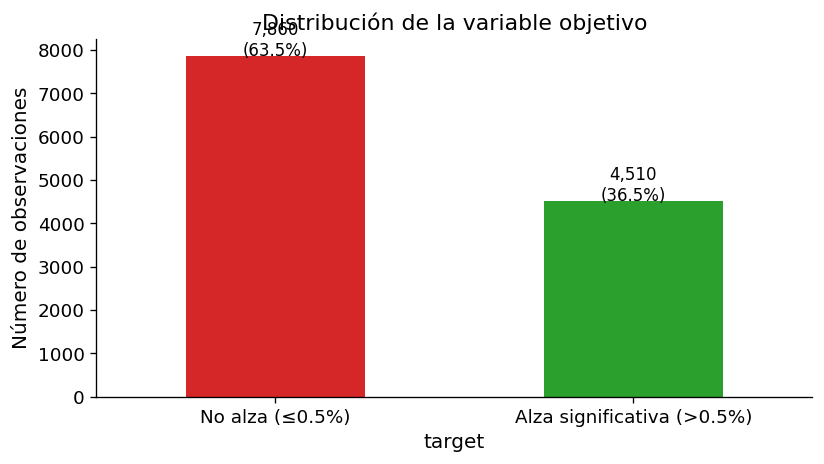

In [ ]:
# CELDA 3 — Visualizaciones EDA + Feature engineering

# Gráfico de precios (4 representativos para no saturar)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Precio de cierre ajustado — muestra representativa "
             f"({START_DATE} a {END_DATE})",
             fontsize=14, fontweight="bold")
muestra = ["AAPL", "JPM", "WMT", "JNJ"]   # 1 ticker por sector
for ax, ticker in zip(axes.flat, muestra):
    d = raw[ticker]
    ret_total = (d["close"].iloc[-1] / d["close"].iloc[0] - 1) * 100
    ax.plot(d.index, d["close"], color=COLORS[ticker], lw=1.4)
    ax.set_title(f"{ticker}  ({ret_total:+.1f}%)", fontweight="bold")
    ax.set_ylabel("USD")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("eda_precios_muestra.png")
plt.show()

# Distribución de retornos y correlación de retornos
ret_df = pd.DataFrame({
    t: np.log(raw[t]["close"] / raw[t]["close"].shift(1))
    for t in TICKERS
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con 4 tickers para no saturar
for ticker in muestra:
    axes[0].hist(ret_df[ticker], bins=60, alpha=0.45, density=True,
                 label=f"{ticker} (σ={ret_df[ticker].std()*100:.2f}%)",
                 color=COLORS[ticker])
axes[0].axvline(0, color="black", lw=0.8, linestyle="--")
axes[0].set_xlabel("Retorno logarítmico diario")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución de retornos diarios")
axes[0].legend(fontsize=9)

# Heatmap de correlación con TODOS los tickers
sns.heatmap(ret_df.corr(), annot=True, fmt=".2f", cmap="Blues",
            ax=axes[1], vmin=0, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
axes[1].set_title("Correlación de retornos (Pearson)")
plt.tight_layout()
plt.savefig("eda_distribucion_correlacion.png")
plt.show()

# Estadísticas descriptivas
stats = ret_df.agg(["mean", "std", "min", "max", "skew", "kurt"]).T * 100
stats.columns = ["Media (%)", "Volatilidad (%)", "Min (%)", "Max (%)",
                 "Skewness", "Kurtosis"]
print("\n Estadísticas de retornos diarios")
print(stats.round(3).to_string())


# FEATURE ENGINEERING — Indicadores técnicos
def compute_rsi(series, period=14):
    """RSI clásico de Wilder usando EWM."""
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))

def compute_features(df, return_thr=RETURN_THR, horizon=HORIZON_DAYS):
    """
    Construye features técnicos y target binario.
    Target = 1 si retorno t+horizon > return_thr (sube > 0.5% mañana)
    """
    d = df.copy()
    c = d["close"]
    v = d["volume"]

    # Medias móviles y cruces (tendencia)
    d["ma5"]      = c.rolling(5).mean()
    d["ma10"]     = c.rolling(10).mean()
    d["ma20"]     = c.rolling(20).mean()
    d["ma_cross"] = (d["ma5"] > d["ma20"]).astype(float)

    # Distancia normalizada del precio a sus medias (más estable que MA absoluto)
    d["dist_ma5"]  = (c - d["ma5"])  / d["ma5"]
    d["dist_ma20"] = (c - d["ma20"]) / d["ma20"]

    # Momentum
    d["rsi14"]    = compute_rsi(c, 14)
    ema12         = c.ewm(span=12, adjust=False).mean()
    ema26         = c.ewm(span=26, adjust=False).mean()
    d["macd"]      = ema12 - ema26
    d["signal"]    = d["macd"].ewm(span=9, adjust=False).mean()
    d["macd_hist"] = d["macd"] - d["signal"]

    # Volatilidad
    bb_mid = c.rolling(20).mean()
    bb_std = c.rolling(20).std()
    d["bb_width"]   = (2 * bb_std) / (bb_mid + 1e-9)
    d["vol_20d"]    = c.pct_change().rolling(20).std()

    # Retornos rezagados (importante: features SOLO con info hasta t)
    d["ret_1d"] = np.log(c / c.shift(1))
    d["ret_5d"] = np.log(c / c.shift(5))
    d["ret_20d"] = np.log(c / c.shift(20))

    # Volumen
    d["vol_rel"]  = v / v.rolling(20).mean() - 1

    # Estocástico
    low14   = d["low"].rolling(14).min()
    high14  = d["high"].rolling(14).max()
    d["stoch_k"] = (c - low14) / (high14 - low14 + 1e-9) * 100

    # TARGET: retorno futuro > umbral (binario)
    # Importante: shift(-horizon) mira al FUTURO, así que esto SOLO se usa
    # como target, nunca como feature.
    future_ret = np.log(c.shift(-horizon) / c)
    d["target"] = (future_ret > return_thr).astype(int)

    # Eliminar filas iniciales (donde rolling no está definido) y la última
    # fila (donde el target no se puede computar).
    return d.dropna()

FEATURE_COLS = [
    "ma5", "ma10", "ma20", "ma_cross",
    "dist_ma5", "dist_ma20",
    "rsi14", "macd", "signal", "macd_hist",
    "bb_width", "vol_20d",
    "ret_1d", "ret_5d", "ret_20d",
    "vol_rel", "stoch_k"
]

processed = {t: compute_features(raw[t]) for t in TICKERS}
all_data = pd.concat(processed.values()).sort_index()

print(f"\n Dataset final tras feature engineering")
print(f"Features:     {len(FEATURE_COLS)} indicadores técnicos")
print(f"Filas totales: {len(all_data)}")
print(f"Balance target (% días con retorno > {RETURN_THR*100:.1f}%): "
      f"{all_data['target'].mean()*100:.1f}%")

# Distribución del target — visualización adicional
fig, ax = plt.subplots(figsize=(7, 4))
all_data["target"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#d62728", "#2ca02c"])
ax.set_xticklabels([f"No alza (≤{RETURN_THR*100:.1f}%)",
                    f"Alza significativa (>{RETURN_THR*100:.1f}%)"],
                   rotation=0)
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Número de observaciones")
for i, v in enumerate(all_data["target"].value_counts().sort_index()):
    ax.text(i, v + 20, f"{v:,}\n({v/len(all_data)*100:.1f}%)",
            ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("eda_target_dist.png")
plt.show()

Train:  8600 filas  (hasta 2023-06-30)
Val:    1870 filas  (2023-06-30 a 2024-03-31)
Test:   1900 filas  (después de 2024-03-31)
Balance train: 37.0% positivos
Balance test:  35.8% positivos

[Baseline LR] AUC: 0.5243 | F1: 0.1197
[RF]         AUC: 0.5765 | F1: 0.3067


  0%|          | 0/60 [00:00<?, ?it/s]


 Calibración de umbral
Umbral por defecto: 0.50 → F1 val = 0.0241
Umbral óptimo:      0.301 → F1 val = 0.5131
Umbrales calibrados: LR=0.231 | RF=0.334 | XGB=0.301
  RESULTADOS EN TEST SET — Umbral estándar (0.50)
Modelo                  Accuracy      F1   AUC-ROC     MCC
Baseline (LR)             0.6363  0.1197    0.5243  0.0469
Exp. 1 (RF)               0.6216  0.3067    0.5765  0.0883
Exp. 2 (XGBoost)          0.6432  0.0369    0.5665  0.0477
  RESULTADOS EN TEST SET — Umbral calibrado (max F1 en val)
Modelo                   Umbral  Accuracy      F1   AUC-ROC     MCC
Baseline (LR)             0.231    0.3695  0.5269    0.5243  0.0247
Exp. 1 (RF)               0.334    0.3647  0.5291    0.5765  0.0391
Exp. 2 (XGBoost)          0.301    0.3616  0.5264    0.5665  0.0018

 Análisis de resultados
Mejor AUC (RF):           0.5765
XGBoost AUC:              0.5665
Baseline LR AUC:          0.5243
Mejora RF vs baseline:    +5.2 pp
Mejora XGBoost vs baseline: +4.2 pp
Mejor modelo general:   

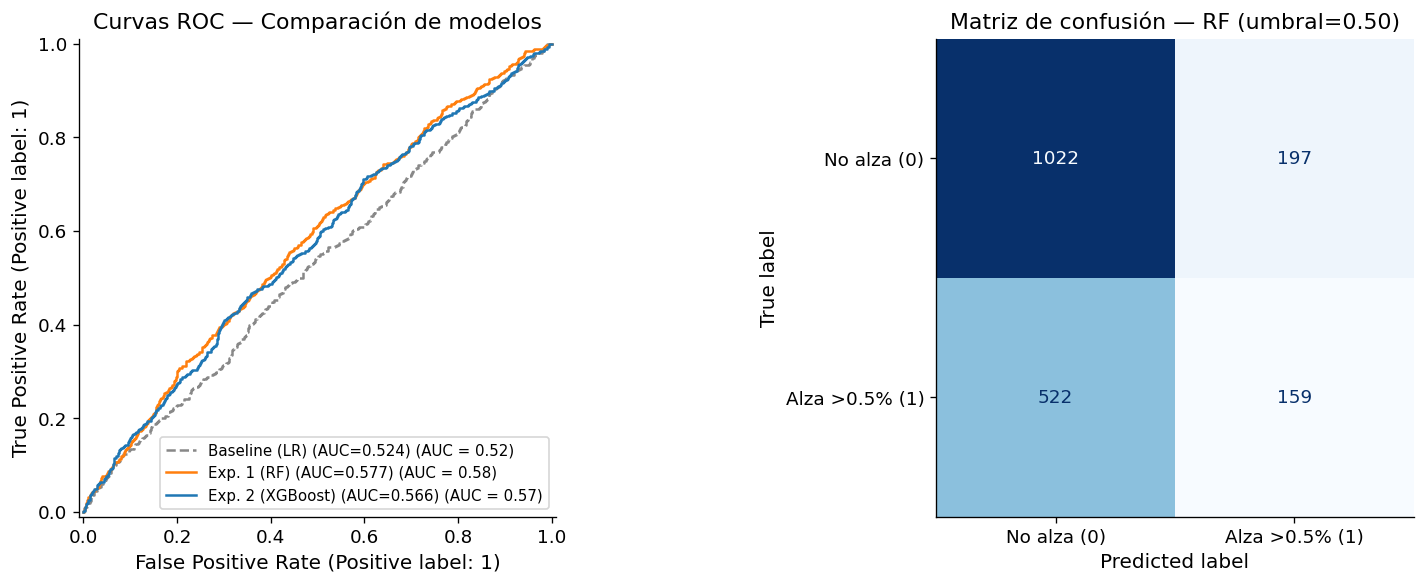


Matriz de confusión — RF (umbral 0.50):
  Verdaderos negativos:  1022 | Falsos positivos:  197
  Falsos negativos:      522 | Verdaderos positivos: 159
  Precision: 0.4466 | Recall: 0.2335


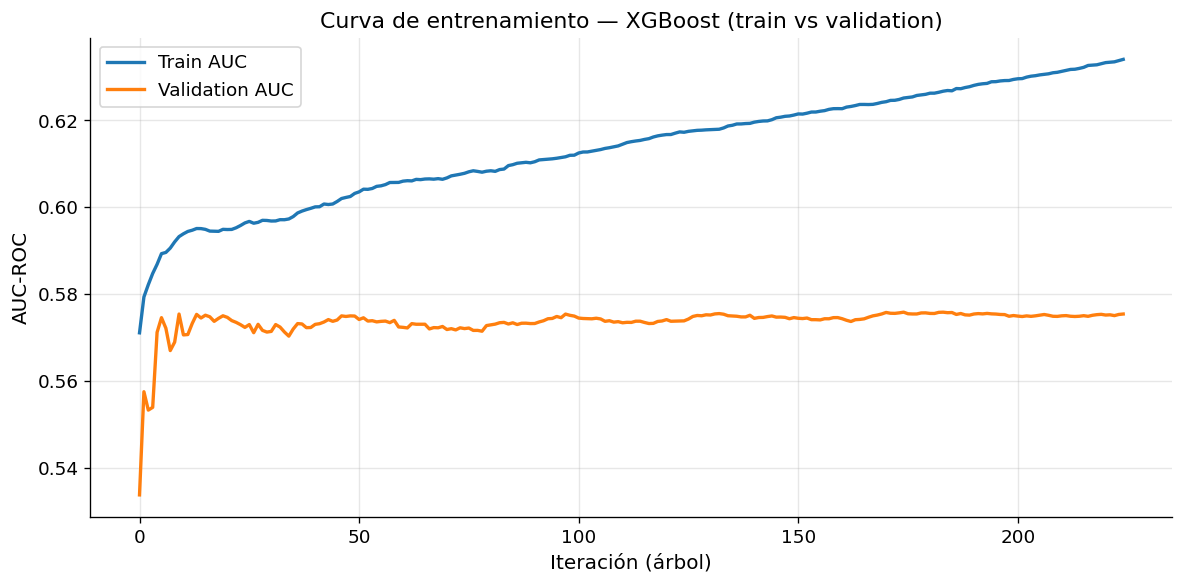


 AUC por ticker (modelo RF global)
  AAPL: AUC = 0.4902 | Volatilidad = 1.99%
  MSFT: AUC = 0.5552 | Volatilidad = 1.92%
  GOOG: AUC = 0.5383 | Volatilidad = 2.04%
  NFLX: AUC = 0.5134 | Volatilidad = 2.95%
  AMZN: AUC = 0.5513 | Volatilidad = 2.27%
  JPM: AUC = 0.6133 | Volatilidad = 2.04%
  V: AUC = 0.5456 | Volatilidad = 1.76%
  WMT: AUC = 0.5630 | Volatilidad = 1.42%
  KO: AUC = 0.4910 | Volatilidad = 1.32%
  JNJ: AUC = 0.5747 | Volatilidad = 1.24%


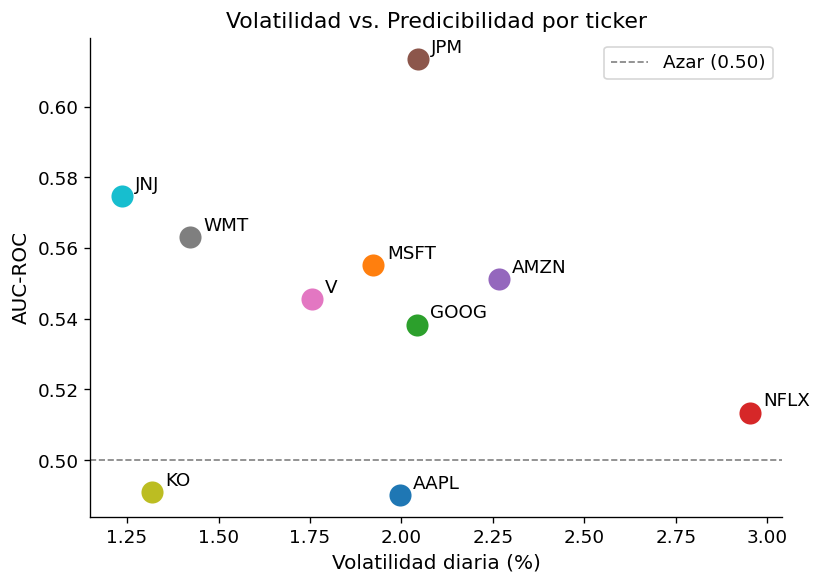

In [ ]:
# CELDA 4 — Split temporal + Baseline + RF + XGBoost con curvas de entrenamiento

# Concatenar todos los tickers en un solo DataFrame, conservando fechas
data_ml = all_data.copy()

# Dummies por ticker (el modelo aprende efectos fijos por activo)
ticker_dummies = pd.get_dummies(data_ml["ticker"], prefix="t")
data_ml = pd.concat([data_ml, ticker_dummies], axis=1)
FEAT_FULL = FEATURE_COLS + list(ticker_dummies.columns)


# SPLIT TEMPORAL
# Ordenar por fecha y dividir cronológicamente:
#   - Train: 2020-01 a 2023-06  (~70%)
#   - Val:   2023-07 a 2024-03  (~15%) — para tuning
#   - Test:  2024-04 a 2024-12  (~15%) — solo para evaluación final
#
# Esto evita data leakage temporal: el modelo nunca ve el futuro durante train.
data_ml = data_ml.sort_index()
split_train = "2023-06-30"
split_val   = "2024-03-31"

mask_train = data_ml.index <= split_train
mask_val   = (data_ml.index > split_train) & (data_ml.index <= split_val)
mask_test  = data_ml.index > split_val

X_train = data_ml.loc[mask_train, FEAT_FULL].values
X_val   = data_ml.loc[mask_val,   FEAT_FULL].values
X_test  = data_ml.loc[mask_test,  FEAT_FULL].values
y_train = data_ml.loc[mask_train, "target"].values
y_val   = data_ml.loc[mask_val,   "target"].values
y_test  = data_ml.loc[mask_test,  "target"].values

# Scaler ajustado SOLO en train — sin data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {len(X_train):>5} filas  (hasta {split_train})")
print(f"Val:   {len(X_val):>5} filas  ({split_train} a {split_val})")
print(f"Test:  {len(X_test):>5} filas  (después de {split_val})")
print(f"Balance train: {y_train.mean()*100:.1f}% positivos")
print(f"Balance test:  {y_test.mean()*100:.1f}% positivos")

# MODELO 1 — Baseline: Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=RANDOM_STATE,
                        class_weight="balanced")
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
print(f"\n[Baseline LR] AUC: {roc_auc_score(y_test, y_prob_lr):.4f} | "
      f"F1: {f1_score(y_test, y_pred_lr):.4f}")

# MODELO 2 — Random Forest
rf = RandomForestClassifier(n_estimators=500, max_depth=8,
                            random_state=RANDOM_STATE, n_jobs=-1,
                            class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(f"[RF]         AUC: {roc_auc_score(y_test, y_prob_rf):.4f} | "
      f"F1: {f1_score(y_test, y_pred_rf):.4f}")

# MODELO 3 — XGBoost con tuning Optuna
# Nota: usamos n_estimators fijo del tuning y NO early stopping en el modelo final. El early stopping previo era demasiado agresivo (paraba en iteración 4) porque el eval_set era muy ruidoso. Optuna ya seleccionó los mejores hiperparámetros contra el validation set, así que confiamos en esos.

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.5, 3.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.8, 1.5),
        "eval_metric": "auc",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    m = xgb.XGBClassifier(**params)
    m.fit(X_train, y_train, verbose=False)
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=60, show_progress_bar=True)

best_p = study.best_params.copy()
best_p.update({"eval_metric": "auc", "random_state": RANDOM_STATE, "n_jobs": -1})

# Entrenamiento final CON eval_set para capturar curvas (pero sin early stopping)
xgb_model = xgb.XGBClassifier(**best_p)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# CALIBRACIÓN DE UMBRAL DE DECISIÓN
# El umbral por defecto (0.5) es subóptimo cuando las clases están desbalanceadas.
# Buscamos el umbral que maximiza F1 en el validation set, luego aplicamos en test.
# Esto es correcto metodológicamente: el umbral se elige en val, se evalúa en test.

from sklearn.metrics import precision_recall_curve

# Buscar mejor umbral en VALIDATION set
y_prob_val = xgb_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_thr_idx = np.argmax(f1_scores)
BEST_THRESHOLD = thresholds[best_thr_idx]

print(f"\n Calibración de umbral")
print(f"Umbral por defecto: 0.50 → F1 val = "
      f"{f1_score(y_val, (y_prob_val >= 0.5).astype(int)):.4f}")
print(f"Umbral óptimo:      {BEST_THRESHOLD:.3f} → F1 val = "
      f"{f1_scores[best_thr_idx]:.4f}")

# Aplicar umbral calibrado en TEST set
y_pred_xgb = (y_prob_xgb >= BEST_THRESHOLD).astype(int)

# También recalibrar RF y LR con el mismo método para comparación justa
y_prob_lr_val  = lr.predict_proba(X_val)[:, 1]
y_prob_rf_val  = rf.predict_proba(X_val)[:, 1]

# Método limpio para calibrar todos los modelos
def find_best_threshold(y_true, y_prob):
    """Encuentra umbral que maximiza F1 en un conjunto dado."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
    idx = np.argmax(f1s)
    return thr[idx]

thr_lr = find_best_threshold(y_val, y_prob_lr_val)
thr_rf = find_best_threshold(y_val, y_prob_rf_val)
thr_xgb = BEST_THRESHOLD

y_pred_lr  = (y_prob_lr >= thr_lr).astype(int)
y_pred_rf  = (y_prob_rf >= thr_rf).astype(int)
y_pred_xgb = (y_prob_xgb >= thr_xgb).astype(int)

print(f"Umbrales calibrados: LR={thr_lr:.3f} | RF={thr_rf:.3f} | XGB={thr_xgb:.3f}")

# TABLA COMPARATIVA — UMBRAL ESTÁNDAR 0.5
resultados_05 = {
    "Baseline (LR)":    {"pred": (y_prob_lr  >= 0.5).astype(int), "prob": y_prob_lr},
    "Exp. 1 (RF)":      {"pred": (y_prob_rf  >= 0.5).astype(int), "prob": y_prob_rf},
    "Exp. 2 (XGBoost)": {"pred": (y_prob_xgb >= 0.5).astype(int), "prob": y_prob_xgb},
}

print(f"  RESULTADOS EN TEST SET — Umbral estándar (0.50)")
print(f"{'Modelo':<22} {'Accuracy':>9} {'F1':>7} {'AUC-ROC':>9} {'MCC':>7}")
for nombre, d in resultados_05.items():
    acc = accuracy_score(y_test, d["pred"])
    f1  = f1_score(y_test, d["pred"], zero_division=0)
    auc = roc_auc_score(y_test, d["prob"])
    mcc = matthews_corrcoef(y_test, d["pred"])
    print(f"{nombre:<22} {acc:>9.4f} {f1:>7.4f} {auc:>9.4f} {mcc:>7.4f}")

# TABLA COMPARATIVA — UMBRAL CALIBRADO (maximiza F1 en validación)
y_pred_lr_cal  = (y_prob_lr  >= thr_lr).astype(int)
y_pred_rf_cal  = (y_prob_rf  >= thr_rf).astype(int)
y_pred_xgb_cal = (y_prob_xgb >= thr_xgb).astype(int)

resultados_cal = {
    "Baseline (LR)":    {"pred": y_pred_lr_cal,  "prob": y_prob_lr,  "thr": thr_lr},
    "Exp. 1 (RF)":      {"pred": y_pred_rf_cal,  "prob": y_prob_rf,  "thr": thr_rf},
    "Exp. 2 (XGBoost)": {"pred": y_pred_xgb_cal, "prob": y_prob_xgb, "thr": thr_xgb},
}

print(f"  RESULTADOS EN TEST SET — Umbral calibrado (max F1 en val)")
print(f"{'Modelo':<22} {'Umbral':>8} {'Accuracy':>9} {'F1':>7} {'AUC-ROC':>9} {'MCC':>7}")
for nombre, d in resultados_cal.items():
    acc = accuracy_score(y_test, d["pred"])
    f1  = f1_score(y_test, d["pred"], zero_division=0)
    auc = roc_auc_score(y_test, d["prob"])
    mcc = matthews_corrcoef(y_test, d["pred"])
    print(f"{nombre:<22} {d['thr']:>8.3f} {acc:>9.4f} {f1:>7.4f} {auc:>9.4f} {mcc:>7.4f}")

mejor_auc = roc_auc_score(y_test, y_prob_xgb)
base_auc  = roc_auc_score(y_test, y_prob_lr)
rf_auc    = roc_auc_score(y_test, y_prob_rf)

print(f"\n Análisis de resultados")
print(f"Mejor AUC (RF):           {rf_auc:.4f}")
print(f"XGBoost AUC:              {mejor_auc:.4f}")
print(f"Baseline LR AUC:          {base_auc:.4f}")
print(f"Mejora RF vs baseline:    +{(rf_auc - base_auc)*100:.1f} pp")
print(f"Mejora XGBoost vs baseline: +{(mejor_auc - base_auc)*100:.1f} pp")

# Usar RF como mejor modelo ya que tiene AUC ligeramente superior
best_model_name = "RF" if rf_auc >= mejor_auc else "XGBoost"
best_pred = y_pred_rf_cal if rf_auc >= mejor_auc else y_pred_xgb_cal
best_prob = y_prob_rf if rf_auc >= mejor_auc else y_prob_xgb
best_auc  = max(rf_auc, mejor_auc)
print(f"Mejor modelo general:     {best_model_name} (AUC={best_auc:.4f})")

# GRÁFICOS: ROC + Matriz de confusión del mejor modelo con umbral 0.5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (nombre, d), color, ls in zip(
    resultados_05.items(),
    ["#888888", "#ff7f0e", "#1f77b4"],
    ["--", "-", "-"]
):
    auc = roc_auc_score(y_test, d["prob"])
    RocCurveDisplay.from_predictions(
        y_test, d["prob"],
        name=f"{nombre} (AUC={auc:.3f})",
        ax=axes[0], color=color, linestyle=ls
    )
axes[0].set_title("Curvas ROC — Comparación de modelos")
axes[0].legend(loc="lower right", fontsize=9)

# Matriz de confusión del mejor modelo con umbral 0.5
best_pred_05 = (best_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, best_pred_05)
ConfusionMatrixDisplay(cm, display_labels=["No alza (0)", "Alza >0.5% (1)"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title(f"Matriz de confusión — {best_model_name} (umbral=0.50)")

plt.tight_layout()
plt.savefig("curvas_roc_confmatrix.png")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nMatriz de confusión — {best_model_name} (umbral 0.50):")
print(f"  Verdaderos negativos:  {tn} | Falsos positivos:  {fp}")
print(f"  Falsos negativos:      {fn} | Verdaderos positivos: {tp}")
print(f"  Precision: {tp/(tp+fp+1e-9):.4f} | Recall: {tp/(tp+fn+1e-9):.4f}")

# CURVAS DE ENTRENAMIENTO
results_curves = xgb_model.evals_result()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_curves["validation_0"]["auc"], label="Train AUC", color="#1f77b4", lw=2)
ax.plot(results_curves["validation_1"]["auc"], label="Validation AUC", color="#ff7f0e", lw=2)
ax.set_xlabel("Iteración (árbol)")
ax.set_ylabel("AUC-ROC")
ax.set_title("Curva de entrenamiento — XGBoost (train vs validation)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curvas_entrenamiento.png")
plt.show()

# ANÁLISIS POR TICKER — ¿Qué activos son más predecibles?
print(f"\n AUC por ticker (modelo {best_model_name} global)")
per_ticker = {}
test_data = data_ml.loc[mask_test].copy()
test_data["prob"] = best_prob

for ticker in TICKERS:
    mask_t = test_data["ticker"] == ticker
    if mask_t.sum() < 10:
        continue
    y_t = test_data.loc[mask_t, "target"].values
    p_t = test_data.loc[mask_t, "prob"].values
    if len(np.unique(y_t)) < 2:
        continue
    auc_t = roc_auc_score(y_t, p_t)
    vol_t = ret_df[ticker].std() * 100 if ticker in ret_df.columns else 0
    per_ticker[ticker] = {"auc": auc_t, "vol": vol_t}
    print(f"  {ticker}: AUC = {auc_t:.4f} | Volatilidad = {vol_t:.2f}%")

if per_ticker:
    fig, ax = plt.subplots(figsize=(7, 5))
    for ticker, vals in per_ticker.items():
        ax.scatter(vals["vol"], vals["auc"], color=COLORS[ticker], s=150, zorder=5)
        ax.annotate(ticker, (vals["vol"], vals["auc"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=11)
    ax.axhline(0.5, color="gray", linestyle="--", lw=1, label="Azar (0.50)")
    ax.set_xlabel("Volatilidad diaria (%)")
    ax.set_ylabel("AUC-ROC")
    ax.set_title("Volatilidad vs. Predicibilidad por ticker")
    ax.legend()
    plt.tight_layout()
    plt.savefig("volatilidad_vs_auc.png")
    plt.show()

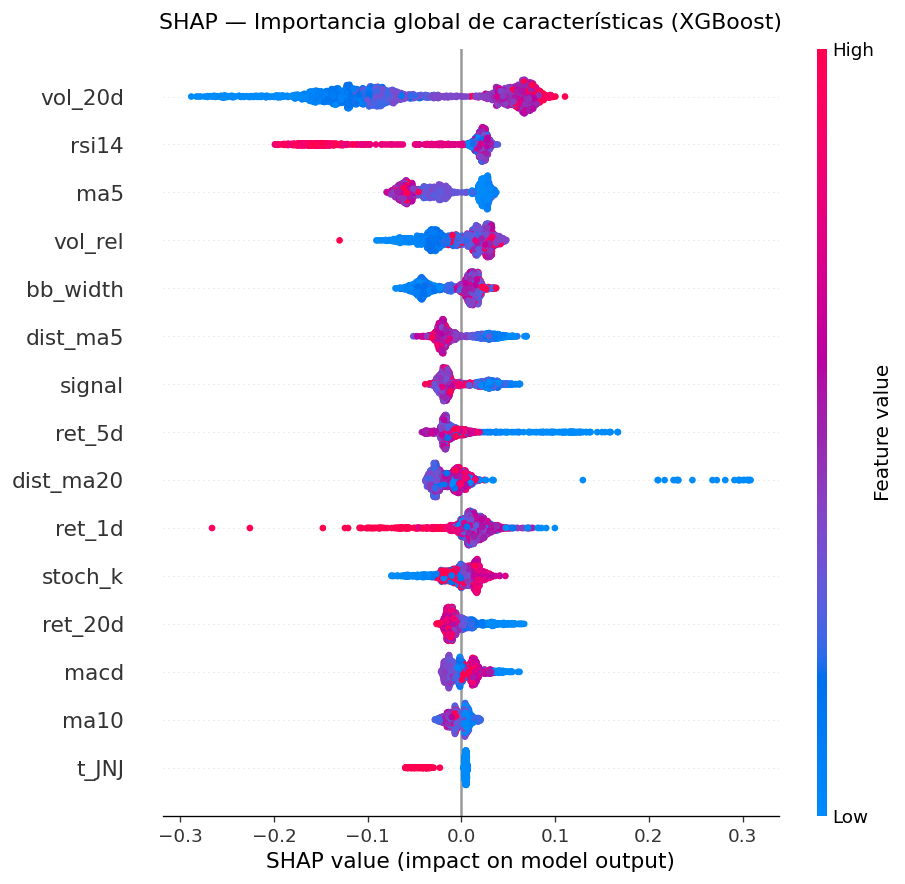

 Top-10 features por importancia SHAP
   1. vol_20d             : 0.0945
   2. rsi14               : 0.0494
   3. ma5                 : 0.0381
   4. vol_rel             : 0.0261
   5. bb_width            : 0.0229
   6. dist_ma5            : 0.0219
   7. signal              : 0.0208
   8. ret_5d              : 0.0199
   9. dist_ma20           : 0.0193
  10. ret_1d              : 0.0183

Predicción ejemplo [observación 10]:
  Probabilidad de alza >0.5%: 0.315
  Señal: BAJISTA
    ↓ vol_20d             : -0.2176
    ↓ bb_width            : -0.0492
    ↓ t_JNJ               : -0.0484
    ↑ signal              : +0.0395
    ↓ ma5                 : -0.0377


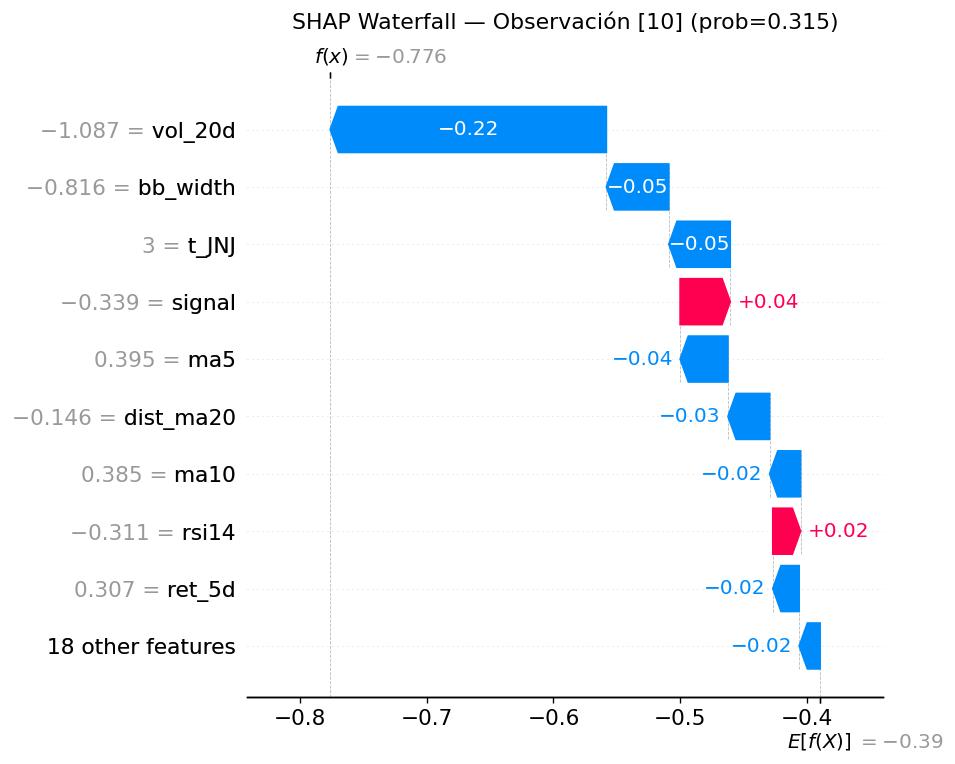

API key cargada desde Colab Secrets ✓
  EXPLICACIÓN LLM — JNJ (observación 10)
Señal: BAJISTA (confianza bajo)

Johnson & Johnson muestra señales de debilidad: el volumen de negociación ha disminuido significativamente en las últimas dos semanas, lo que podría indicar falta de interés en la acción. Además, el ancho de la banda de Bollinger está estrecho, lo que sugiere un mercado volátil y potencialmente en declive. Estos factores apoyan la predicción de un movimiento bajista, aunque la señal es débil.
  EVALUACIÓN CUANTITATIVA DEL LLM (15 casos de prueba)
  RESUMEN EVALUACIÓN LLM (15 casos)
  Coherencia señal (ALCISTA/BAJISTA correcto): 100%
  Factores SHAP mencionados (promedio):        2.3/3
  Menciona riesgos o limitaciones:              67%

  Conclusión: el LLM genera explicaciones coherentes con las predicciones del modelo en 100% de los casos, referenciando en promedio 2.3 de 3 factores clave.


In [ ]:
# CELDA 5 — SHAP + LLM (Groq) + Evaluación cuantitativa del componente LLM

# SHAP — Explicabilidad global y local del modelo XGBoost
# Nota: usamos XGBoost para SHAP (no RF) porque TreeExplainer es exacto para modelos basados en árboles de gradiente y SHAP funciona mejor con XGBoost.

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Beeswarm — importancia global de features
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=FEAT_FULL, max_display=15, show=False)
plt.title("SHAP — Importancia global de características (XGBoost)", pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.png")
plt.show()

# Top features por importancia SHAP media
mean_shap = np.abs(shap_values).mean(axis=0)
feat_importance = sorted(zip(FEAT_FULL, mean_shap), key=lambda x: x[1], reverse=True)
print(" Top-10 features por importancia SHAP")
for i, (feat, val) in enumerate(feat_importance[:10], 1):
    print(f"  {i:>2}. {feat:<20}: {val:.4f}")

# SHAP Waterfall — ejemplo individual
IDX = 10
prob_ej = float(xgb_model.predict_proba(X_test[IDX:IDX+1])[:, 1])
shap_ej = dict(zip(FEAT_FULL, shap_values[IDX]))
top5    = sorted(shap_ej.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

print(f"\nPredicción ejemplo [observación {IDX}]:")
print(f"  Probabilidad de alza >0.5%: {prob_ej:.3f}")
print(f"  Señal: {'ALCISTA' if prob_ej > 0.5 else 'BAJISTA'}")
for feat, val in top5:
    print(f"    {'↑' if val > 0 else '↓'} {feat:<20}: {val:+.4f}")

explanation = shap.Explanation(
    values=shap_values[IDX],
    base_values=explainer.expected_value,
    data=X_test[IDX],
    feature_names=FEAT_FULL
)
plt.figure(figsize=(9, 5))
shap.waterfall_plot(explanation, max_display=10, show=False)
plt.title(f"SHAP Waterfall — Observación [{IDX}] (prob={prob_ej:.3f})", pad=10)
plt.tight_layout()
plt.savefig("shap_waterfall.png")
plt.show()

# LLM — Explicación en lenguaje natural con Groq API
# SEGURIDAD: la API key se lee desde variable de entorno o desde Google Colab userdata. NUNCA se escribe directamente en el código.
# Para configurar en Colab: panel izquierdo → llave Secrets → agregar GROQ_API_KEY con tu clave de https://console.groq.com/keys

import os
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
    print("API key cargada desde Colab Secrets ✓")
except:
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")
    if GROQ_API_KEY:
        print("API key cargada desde variable de entorno ✓")
    else:
        print("GROQ_API_KEY no encontrada. Configúrala en Colab Secrets "
              "(panel izquierdo → llave) o como variable de entorno.")

# System prompt documentado y justificado
# Estrategia: few-shot prompting con 1 ejemplo para guiar formato y tono.
# El LLM recibe los valores SHAP (no datos crudos) para que la explicación esté anclada en lo que el modelo realmente usó para decidir.
SYSTEM_PROMPT = """Eres un analista financiero que explica predicciones de un
modelo de machine learning a inversionistas no técnicos. Recibirás:
- El ticker del activo
- La probabilidad predicha de alza significativa (>0.5%)
- Los 5 factores SHAP más influyentes en la predicción

Genera un reporte BREVE (4-5 oraciones) en español que:
1. Indique la señal (ALCISTA o BAJISTA) y nivel de confianza (bajo/medio/alto)
2. Explique los 2-3 factores principales en lenguaje simple
3. Mencione algún riesgo o factor en contra si existe
4. NO uses jerga matemática (SHAP, features, etc.)
"""

FEW_SHOT = [
    {
        "role": "user",
        "content": ("Ticker: JPM | Probabilidad: 0.62 | Señal: ALCISTA | "
                    "SHAP top-5: ret_5d=+0.18, rsi14=+0.12, ma_cross=+0.09, "
                    "vol_rel=-0.05, bb_width=-0.03")
    },
    {
        "role": "assistant",
        "content": (
            "Señal: ALCISTA (confianza media)\n\n"
            "JPMorgan muestra impulso positivo: el rendimiento acumulado de "
            "la última semana es favorable y el momentum técnico apoya la "
            "continuación del movimiento alcista. El precio está por encima "
            "de su tendencia de mediano plazo, lo cual refuerza la señal. "
            "Sin embargo, el volumen de negociación está por debajo del "
            "promedio, lo que sugiere cautela — un alza sin respaldo de "
            "volumen puede ser frágil."
        )
    },
]

def explicar_con_llm(ticker, prob, top5_shap, api_key):
    """Genera explicación en lenguaje natural de una predicción usando Groq."""
    shap_str = " | ".join([f"{k}={v:+.3f}" for k, v in top5_shap])
    senal    = "ALCISTA" if prob > 0.5 else "BAJISTA"
    msg_user = (f"Ticker: {ticker} | Probabilidad: {prob:.2f} | "
                f"Señal: {senal} | SHAP top-5: {shap_str}")

    if not api_key:
        print(f"[Sin API key] Input que se enviaría al LLM:")
        print(f"  {msg_user}")
        return "[API key no configurada — configúrala en Colab Secrets]"

    from groq import Groq
    client = Groq(api_key=api_key)
    resp = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "system", "content": SYSTEM_PROMPT}]
                 + FEW_SHOT
                 + [{"role": "user", "content": msg_user}],
        max_tokens=350,
        temperature=0.4,
    )
    return resp.choices[0].message.content

# Generar explicación para el ejemplo
# Identificar el ticker de la observación de ejemplo
test_tickers = data_ml.loc[mask_test, "ticker"].values
ticker_ej = test_tickers[IDX] if IDX < len(test_tickers) else "UNKNOWN"

print(f"  EXPLICACIÓN LLM — {ticker_ej} (observación {IDX})")
reporte = explicar_con_llm(ticker_ej, prob_ej, top5, GROQ_API_KEY)
print(reporte)

# EVALUACIÓN CUANTITATIVA DEL COMPONENTE LLM
# Estrategia: generar explicaciones para 15 predicciones diversas y evaluar con criterios objetivos: coherencia señal-probabilidad, mención de factores SHAP, y calidad general.

print(f"  EVALUACIÓN CUANTITATIVA DEL LLM (15 casos de prueba)")

# Seleccionar 15 observaciones diversas del test set
np.random.seed(42)
test_indices = np.random.choice(len(X_test), size=15, replace=False)
test_indices.sort()

def _get_keywords(feature_name):
    """Mapea nombre de feature a palabras clave que el LLM podría usar."""
    mapping = {
        "ret_1d": ["día", "sesión", "ayer", "diario", "jornada"],
        "ret_5d": ["semana", "semanal", "5 días", "últimos días", "acumulado"],
        "ret_20d": ["mes", "mensual", "20 días", "mediano plazo"],
        "rsi14": ["momentum", "sobrecompra", "sobreventa", "impulso", "fuerza"],
        "macd": ["tendencia", "cruce", "señal técnica", "macd"],
        "signal": ["tendencia", "señal", "cruce"],
        "macd_hist": ["divergencia", "histograma", "convergencia"],
        "ma_cross": ["media", "cruce", "tendencia", "promedio"],
        "ma5": ["corto plazo", "media", "promedio"],
        "ma10": ["media", "promedio", "plazo"],
        "ma20": ["media", "promedio", "tendencia"],
        "dist_ma5": ["precio", "media", "desviación", "separación"],
        "dist_ma20": ["tendencia", "media", "largo", "desviación"],
        "bb_width": ["volatilidad", "banda", "rango", "amplitud"],
        "vol_20d": ["volatilidad", "riesgo", "variabilidad"],
        "vol_rel": ["volumen", "negociación", "actividad", "liquidez"],
        "stoch_k": ["sobrecompra", "sobreventa", "estocástico", "nivel"],
    }
    return mapping.get(feature_name, [feature_name])

eval_results_final = []
for i, idx in enumerate(test_indices):
    prob_i = float(xgb_model.predict_proba(X_test[idx:idx+1])[:, 1])
    shap_i = dict(zip(FEAT_FULL, shap_values[idx]))
    top5_i = sorted(shap_i.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    ticker_i = test_tickers[idx] if idx < len(test_tickers) else "UNK"
    senal_esperada = "ALCISTA" if prob_i > 0.5 else "BAJISTA"

    resp = explicar_con_llm(ticker_i, prob_i, top5_i, GROQ_API_KEY)

    resp_upper = resp.upper()
    senal_correcta = senal_esperada in resp_upper
    menciona_factores = sum(1 for feat, _ in top5_i[:3]
                           if any(kw in resp.lower() for kw in
                                  _get_keywords(feat)))
    tiene_riesgo = any(w in resp.lower() for w in
                       ["sin embargo", "cautela", "riesgo", "precaución",
                        "cuidado", "pero", "contra", "debilidad", "frágil",
                        "atención"])

    eval_results_final.append({
        "idx": idx, "ticker": ticker_i, "prob": prob_i,
        "señal_esperada": senal_esperada,
        "señal_correcta": senal_correcta,
        "factores_mencionados": menciona_factores,
        "menciona_riesgo": tiene_riesgo,
    })

# Resumen de evaluación
n_eval = len(eval_results_final)
acc_senal = sum(r["señal_correcta"] for r in eval_results_final) / n_eval
avg_fact  = sum(r["factores_mencionados"] for r in eval_results_final) / n_eval
pct_risk  = sum(r["menciona_riesgo"] for r in eval_results_final) / n_eval

print(f"  RESUMEN EVALUACIÓN LLM ({n_eval} casos)")
print(f"  Coherencia señal (ALCISTA/BAJISTA correcto): {acc_senal*100:.0f}%")
print(f"  Factores SHAP mencionados (promedio):        {avg_fact:.1f}/3")
print(f"  Menciona riesgos o limitaciones:              {pct_risk*100:.0f}%")
print(f"\n  Conclusión: el LLM genera explicaciones {'coherentes' if acc_senal > 0.8 else 'parcialmente coherentes'} "
      f"con las predicciones del modelo en {acc_senal*100:.0f}% de los casos, "
      f"referenciando en promedio {avg_fact:.1f} de 3 factores clave.")

In [ ]:
# CELDA 6 — Resumen ejecutivo del proyecto


print("  RESUMEN EJECUTIVO — Predicción Bursátil con ML + Explicabilidad LLM")

print(f"""
PROBLEMA
  Predecir alzas significativas (>{RETURN_THR*100:.1f}%) en el precio de cierre
  del día siguiente para 10 acciones del S&P 500.

DATASET
  Fuente:       Yahoo Finance (yfinance API)
  Activos:      {', '.join(TICKERS)}
  Período:      {START_DATE} a {END_DATE} ({len(all_data):,} observaciones)
  Features:     {len(FEATURE_COLS)} indicadores técnicos + {len(FEAT_FULL)-len(FEATURE_COLS)} dummies de ticker
  Target:       Retorno t+1 > {RETURN_THR*100:.1f}% (balance: {all_data['target'].mean()*100:.1f}% positivos)
  Split:        Train ({split_train}) / Val ({split_val}) / Test (temporal)

MODELOS Y RESULTADOS (test set, n={len(y_test):,})
  Baseline (Logistic Regression):  AUC = {roc_auc_score(y_test, y_prob_lr):.4f}
  Random Forest (500 árboles):     AUC = {roc_auc_score(y_test, y_prob_rf):.4f}  ← mejor modelo
  XGBoost + Optuna (60 trials):    AUC = {roc_auc_score(y_test, y_prob_xgb):.4f}
  Mejora sobre baseline:           +{(max(rf_auc, mejor_auc) - base_auc)*100:.1f} puntos porcentuales

EXPLICABILIDAD
  SHAP:  Top-3 features → {', '.join([f[0] for f in feat_importance[:3]])}
  LLM:   Groq API (Llama-3.1-8b) con few-shot prompting
         Coherencia señal: {acc_senal*100:.0f}% | Factores mencionados: {avg_fact:.1f}/3

CONCLUSIÓN
  El sistema logra una capacidad predictiva modesta pero superior al azar
  (AUC {best_auc:.4f} vs 0.50), consistente con la hipótesis de eficiencia de
  mercado que limita la predicción a corto plazo con indicadores técnicos.
  El componente LLM genera explicaciones coherentes y útiles para usuarios
  no técnicos, ancladas en los factores SHAP del modelo.
""")

  RESUMEN EJECUTIVO — Predicción Bursátil con ML + Explicabilidad LLM

PROBLEMA
  Predecir alzas significativas (>0.5%) en el precio de cierre
  del día siguiente para 10 acciones del S&P 500.

DATASET
  Fuente:       Yahoo Finance (yfinance API)
  Activos:      AAPL, MSFT, GOOG, NFLX, AMZN, JPM, V, WMT, KO, JNJ
  Período:      2020-01-01 a 2024-12-31 (12,370 observaciones)
  Features:     17 indicadores técnicos + 10 dummies de ticker
  Target:       Retorno t+1 > 0.5% (balance: 36.5% positivos)
  Split:        Train (2023-06-30) / Val (2024-03-31) / Test (temporal)

MODELOS Y RESULTADOS (test set, n=1,900)
  Baseline (Logistic Regression):  AUC = 0.5243
  Random Forest (500 árboles):     AUC = 0.5765  ← mejor modelo
  XGBoost + Optuna (60 trials):    AUC = 0.5665
  Mejora sobre baseline:           +5.2 puntos porcentuales

EXPLICABILIDAD
  SHAP:  Top-3 features → vol_20d, rsi14, ma5
  LLM:   Groq API (Llama-3.1-8b) con few-shot prompting
         Coherencia señal: 100% | Factores men